# IT3091 - Member 3 - IT24101090 - JAYAKODY N.D


In [1]:
from pathlib import Path

REPO_PATH = Path("/content/IT3091---Machine-Learning-Assignment")

if not REPO_PATH.exists():
    !git clone https://github.com/DTD-Wijesinghe/IT3091---Machine-Learning-Assignment.git

%cd /content/IT3091---Machine-Learning-Assignment

Cloning into 'IT3091---Machine-Learning-Assignment'...
remote: Enumerating objects: 169, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 169 (delta 14), reused 20 (delta 3), pack-reused 132 (from 1)
Receiving objects: 100% (169/169), 8.42 MiB | 15.97 MiB/s, done.
Resolving deltas: 100% (56/56), done.
/content/IT3091---Machine-Learning-Assignment


## Member 3 - Price data, EDA and preprocessing

In [2]:
!pip -q install openpyxl joblib

import os
import re
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

REPO_PATH = Path("/content/IT3091---Machine-Learning-Assignment")
RAW_PATH = REPO_PATH / "Raw Datasets"
PREPROCESSED_PATH = REPO_PATH / "Preprocessed Datasets"
EVIDENCE_PATH = REPO_PATH / "Evidence Logs"

PREPROCESSED_PATH.mkdir(parents=True, exist_ok=True)
EVIDENCE_PATH.mkdir(parents=True, exist_ok=True)

print("Raw data:", RAW_PATH)
print("Preprocessed data:", PREPROCESSED_PATH)
print("Evidence logs:", EVIDENCE_PATH)

Raw data: /content/IT3091---Machine-Learning-Assignment/Raw Datasets
Preprocessed data: /content/IT3091---Machine-Learning-Assignment/Preprocessed Datasets
Evidence logs: /content/IT3091---Machine-Learning-Assignment/Evidence Logs


In [3]:
PRODUCTION_PREP = (
    PREPROCESSED_PATH
    / "01_production_preprocessed.csv"
)

WEATHER_PREP = (
    PREPROCESSED_PATH
    / "02_weather_preprocessed.csv"
)

price_matches = list(
    RAW_PATH.glob(
        "*Weekly*Average*Retail*Prices*.xlsx"
    )
)

if not price_matches:
    price_matches = list(
        RAW_PATH.glob("*Weekly*Prices*.xlsx")
    )

if not price_matches:
    raise FileNotFoundError(
        "Weekly vegetable price workbook was not found in Raw Datasets."
    )

PRICE_FILE = price_matches[0]

if not PRODUCTION_PREP.exists():
    raise FileNotFoundError(
        "Member 1 file 01_production_preprocessed.csv is missing."
    )

if not WEATHER_PREP.exists():
    raise FileNotFoundError(
        "Member 2 file 02_weather_preprocessed.csv is missing."
    )

prod = pd.read_csv(PRODUCTION_PREP)

weather_3m = pd.read_csv(
    WEATHER_PREP,
    parse_dates=[
        "ForecastDate",
        "WeatherWindowStart",
        "WeatherWindowEnd"
    ]
)

required_weather_cols = {
    "Year",
    "Season",
    "ForecastDate",
    "WeatherWindowStart",
    "WeatherWindowEnd",
    "Rainfall_3M_mm",
    "TempMean_3M_C",
    "WindSpeed_3M_kmh",
    "SolarRadiation_3M_MJ_m2",
    "ET0_3M_mm",
    "Leakage_Check"
}

missing_weather = (
    required_weather_cols
    - set(weather_3m.columns)
)

if missing_weather:
    raise KeyError(
        "Member 2 file is not the corrected leakage-safe version. "
        f"Missing columns: {sorted(missing_weather)}"
    )

if not (
    weather_3m["WeatherWindowEnd"]
    < weather_3m["ForecastDate"]
).all():
    raise ValueError(
        "Future weather leakage found in Member 2 output."
    )

prod = prod[
    prod["Year"].between(2012, 2023)
].copy()

weather_3m = weather_3m[
    weather_3m["Year"].between(2012, 2023)
].copy()

print("Production rows:", len(prod))
print("Weather rows:", len(weather_3m))
print("Price file:", PRICE_FILE.name)

Production rows: 592
Weather rows: 24
Price file: Weekly Average Retail Prices of Vegi - 2012 to 2025.xlsx


In [4]:
preview = pd.read_excel(
    PRICE_FILE,
    header=None,
    nrows=15
)

header_row = None

for i, row in preview.iterrows():
    values = [
        str(v).strip().lower()
        for v in row.values
    ]

    if "market type" in values:
        header_row = i
        break

if header_row is None:
    raise ValueError(
        "Could not find the Market Type header."
    )

price_raw = pd.read_excel(
    PRICE_FILE,
    header=header_row
)

price_raw.columns = [
    re.sub(r"\s+", " ", str(c)).strip()
    for c in price_raw.columns
]

price_raw = price_raw.loc[
    :,
    ~price_raw.columns
    .astype(str)
    .str.startswith("Unnamed")
]

print("Price shape:", price_raw.shape)
display(price_raw.head())

Price shape: (730, 55)


,Year,Market Type,Commodity,W1,W2,W3,W4,W5,W6,W7,W8,W9,W10,W11,W12,W13,W14,W15,W16,W17,W18,W19,W20,W21,W22,W23,W24,W25,W26,W27,W28,W29,W30,W31,W32,W33,W34,W35,W36,W37,W38,W39,W40,W41,W42,W43,W44,W45,W46,W47,W48,W49,W50,W51,W52
0,2012,Wholesale,GREEN BEANS,90.00,64.0,50.0,66.00,54.00,41.36,50.45,63.75,42.50,47.50,49.09,NaN,44.0,27.0,54.0,68.0,93.0,112.0,80.00,76.0,60.91,70.46,121.67,126.00,124.0,137.00,95.00,66.00,64.54,69.09,75.00,81.36,63.00,78.0,73.63,75.00,70.00,86.0,87.00,100.91,124.0,114.0,131.00,158.75,208.89,190.00,155.00,145.71,118.75,45.00,53.75,42.22
1,2012,Wholesale,CARROT,103.64,70.5,65.0,62.73,53.89,49.54,44.50,46.25,35.50,35.50,35.91,NaN,41.0,36.5,31.0,42.0,27.5,29.0,42.00,44.0,71.36,61.36,65.83,131.67,116.0,85.56,104.17,86.00,76.37,85.83,114.54,111.82,83.63,83.0,80.67,85.50,71.82,64.0,73.50,78.00,74.0,79.0,91.11,133.75,155.56,167.50,178.75,188.75,161.25,143.75,145.87,113.75
2,2012,Wholesale,LEEKS,49.00,51.0,47.5,46.50,53.50,48.50,48.60,48.34,48.50,48.50,51.82,NaN,52.5,55.0,52.5,76.0,53.0,74.0,108.89,120.0,127.00,97.73,111.67,115.00,116.0,108.89,113.34,88.00,68.18,82.92,96.36,82.00,59.00,67.0,66.00,64.17,56.82,55.0,51.00,55.00,56.0,58.5,43.89,56.25,39.38,55.63,56.25,55.00,66.25,65.00,88.75,66.25
3,2012,Wholesale,BEETROOT,84.33,83.0,73.0,91.25,62.50,56.11,49.55,42.50,36.00,33.80,42.00,NaN,37.5,41.0,40.0,42.0,46.5,76.0,79.00,101.0,110.00,91.25,104.17,88.33,85.0,97.73,114.54,86.00,79.09,68.64,71.67,74.17,51.00,66.0,64.54,63.64,57.00,60.5,60.00,63.33,56.0,56.0,51.11,68.00,73.75,89.17,75.00,88.75,87.00,82.50,68.75,89.00
4,2012,Wholesale,KNOL-KHOL,NaN,NaN,60.0,58.00,56.67,45.00,50.00,37.27,38.57,38.57,38.57,NaN,37.0,33.5,33.0,33.0,39.0,40.0,41.00,54.5,64.00,55.91,60.00,69.00,64.0,59.00,36.67,28.33,32.50,37.27,36.82,37.27,34.50,27.0,22.00,21.37,20.87,24.5,35.63,42.22,44.0,42.5,45.00,63.75,65.00,90.00,92.50,80.00,78.87,88.75,85.00,81.43


In [5]:
price = price_raw[
    price_raw["Market Type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("wholesale")
].copy()

price["Year"] = pd.to_numeric(
    price["Year"],
    errors="coerce"
)

price = price.dropna(
    subset=["Year", "Commodity"]
).copy()

price["Year"] = price["Year"].astype(int)

week_cols = [
    c for c in price.columns
    if re.fullmatch(
        r"W\d+",
        str(c).strip(),
        flags=re.I
    )
]

if not week_cols:
    raise ValueError(
        "No weekly W1, W2, ... columns were found."
    )

price_long = price.melt(
    id_vars=[
        "Year",
        "Market Type",
        "Commodity"
    ],
    value_vars=week_cols,
    var_name="Week",
    value_name="WholesalePrice_RsKg"
)

price_long["WeekNum"] = pd.to_numeric(
    price_long["Week"]
    .astype(str)
    .str.extract(r"(\d+)")[0],
    errors="coerce"
)

price_long["WholesalePrice_RsKg"] = (
    pd.to_numeric(
        price_long["WholesalePrice_RsKg"],
        errors="coerce"
    )
)

price_long = price_long.dropna(
    subset=[
        "WeekNum",
        "WholesalePrice_RsKg"
    ]
).copy()

price_long["WeekNum"] = (
    price_long["WeekNum"].astype(int)
)

iso = (
    price_long["Year"].astype(str)
    + "-W"
    + price_long["WeekNum"]
    .astype(str)
    .str.zfill(2)
    + "-1"
)

price_long["WeekDate"] = (
    pd.to_datetime(
        iso,
        format="%G-W%V-%u",
        errors="coerce"
    )
)

price_long = price_long.dropna(
    subset=["WeekDate"]
).copy()

price_long["MonthDate"] = (
    price_long["WeekDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print("Wholesale weekly rows:", len(price_long))

Wholesale weekly rows: 15598


In [6]:
def norm_text(x):
    x = str(x).upper().strip()
    x = re.sub(
        r"[^A-Z0-9]+",
        " ",
        x
    )
    return re.sub(
        r"\s+",
        " ",
        x
    ).strip()


PRICE_TO_PRODUCTION = {
    "GREEN BEANS": "Beans",
    "CARROT": "Carrot",
    "LEEKS": "Leeks",
    "BEETROOT": "Beetroot",
    "KNOL KHOL": "Knolkhol",
    "RADDISH": "Raddish",
    "CABBAGE": "Cabbage",
    "TOMATOES": "Tomatoes",
    "BRINJALS": "Brinjals",
    "CAPSICUM": "Capsicum",
    "ASH PLANTAINS": "Ash Plantain",
    "BITTER GOURD": "Bitter Gourd",
    "CUCUMBER": "Cucumber",
    "DRUMSTIC": "Drumstics",
    "LADIES FINGERS": "Bandakka",
    "LONG BEANS": "Long Bean",
    "LUFFA": "Luffa",
    "SNAKE GOURD": "Snake Gourd"
}

price_long["CommodityKey"] = (
    price_long["Commodity"].map(norm_text)
)

price_long["Crop"] = (
    price_long["CommodityKey"]
    .map(PRICE_TO_PRODUCTION)
)

unmapped = sorted(
    price_long.loc[
        price_long["Crop"].isna(),
        "CommodityKey"
    ]
    .dropna()
    .unique()
)

print("Unmapped commodities not used:")
print(unmapped)

price_long = price_long.dropna(
    subset=["Crop"]
).copy()

print("Mapped crops:", price_long["Crop"].nunique())

Unmapped commodities not used:
['GOTUKOLA', 'GREEN CHILLIES', 'KANKUN', 'LIME', 'MANIOC', 'MUKUNUWENNA', 'PUMPKIN', 'SWEET POTATOES']
Mapped crops: 18


In [7]:
monthly = (
    price_long
    .groupby(
        ["Crop", "MonthDate"],
        as_index=False
    )["WholesalePrice_RsKg"]
    .mean()
    .sort_values(
        ["Crop", "MonthDate"]
    )
)

parts = []

for crop, g in monthly.groupby("Crop"):
    g = (
        g
        .set_index("MonthDate")
        .sort_index()
    )

    full_idx = pd.date_range(
        g.index.min(),
        g.index.max(),
        freq="MS"
    )

    g = g.reindex(full_idx)
    g.index.name = "MonthDate"
    g["Crop"] = crop

    g["PrevMonthWholesalePrice_RsKg"] = (
        g["WholesalePrice_RsKg"].shift(1)
    )

    g["NextMonthWholesalePrice_RsKg"] = (
        g["WholesalePrice_RsKg"].shift(-1)
    )

    parts.append(g.reset_index())

price_monthly = pd.concat(
    parts,
    ignore_index=True
)

price_output = (
    PREPROCESSED_PATH
    / "03_price_preprocessed.csv"
)

price_monthly.to_csv(
    price_output,
    index=False
)

print("Saved:", price_output)
display(price_monthly.head())

Saved: /content/IT3091---Machine-Learning-Assignment/Preprocessed Datasets/03_price_preprocessed.csv


,MonthDate,Crop,WholesalePrice_RsKg,PrevMonthWholesalePrice_RsKg,NextMonthWholesalePrice_RsKg
0,2012-01-01,Ash Plantain,41.372000,NaN,33.335000
1,2012-02-01,Ash Plantain,33.335000,41.372000,24.166667
2,2012-03-01,Ash Plantain,24.166667,33.335000,21.180000
3,2012-04-01,Ash Plantain,21.180000,24.166667,17.680000
4,2012-05-01,Ash Plantain,17.680000,21.180000,24.472500


In [8]:
SEASON_ANCHOR_MONTH = {
    "Yala": 4,
    "Maha": 9
}

prod["AnchorMonth"] = (
    prod["Season"]
    .map(SEASON_ANCHOR_MONTH)
)

if prod["AnchorMonth"].isna().any():
    bad_seasons = sorted(
        prod.loc[
            prod["AnchorMonth"].isna(),
            "Season"
        ]
        .dropna()
        .unique()
    )
    raise ValueError(
        f"Unexpected production seasons: {bad_seasons}"
    )

prod["AnchorDate"] = pd.to_datetime({
    "year": prod["Year"],
    "month": prod["AnchorMonth"],
    "day": 1
})

model_data = prod.merge(
    weather_3m,
    on=["Year", "Season"],
    how="left",
    validate="many_to_one"
)

weather_missing = (
    model_data["ForecastDate"].isna().sum()
)

if weather_missing:
    raise ValueError(
        f"{weather_missing} production rows did not match weather features."
    )

anchor_mismatch = (
    model_data["AnchorDate"]
    != model_data["ForecastDate"]
)

if anchor_mismatch.any():
    raise ValueError(
        "AnchorDate and weather ForecastDate do not match."
    )

price_for_merge = price_monthly[
    [
        "Crop",
        "MonthDate",
        "PrevMonthWholesalePrice_RsKg",
        "NextMonthWholesalePrice_RsKg"
    ]
].copy()

model_data = model_data.merge(
    price_for_merge,
    left_on=[
        "Crop",
        "AnchorDate"
    ],
    right_on=[
        "Crop",
        "MonthDate"
    ],
    how="left",
    validate="many_to_one"
)

model_data = model_data[
    model_data["Year"].between(
        2012,
        2023
    )
].copy()

required_model_cols = [
    "Yield_t_ha",
    "PrevMonthWholesalePrice_RsKg",
    "NextMonthWholesalePrice_RsKg",
    "Rainfall_3M_mm",
    "TempMean_3M_C",
    "WindSpeed_3M_kmh",
    "SolarRadiation_3M_MJ_m2",
    "ET0_3M_mm"
]

missing_before = (
    model_data[required_model_cols]
    .isna()
    .sum()
)

print("Missing required values before final filtering:")
display(
    missing_before
    .to_frame("missing")
)

model_data = model_data.dropna(
    subset=required_model_cols
).copy()

model_data = model_data.drop(
    columns=["MonthDate"],
    errors="ignore"
)

if not (
    pd.to_datetime(
        model_data["WeatherWindowEnd"]
    )
    <
    pd.to_datetime(
        model_data["ForecastDate"]
    )
).all():
    raise ValueError(
        "Weather leakage found in final modelling dataset."
    )

duplicate_key_rows = (
    model_data
    .duplicated(
        ["Crop", "Season", "Year"]
    )
    .sum()
)

if duplicate_key_rows:
    raise ValueError(
        f"Duplicate Crop+Season+Year rows found: {duplicate_key_rows}"
    )

print("Final modelling shape:", model_data.shape)
print(
    "Year range:",
    model_data["Year"].min(),
    "-",
    model_data["Year"].max()
)
print(
    "Crops:",
    model_data["Crop"].nunique()
)

display(model_data.head())

Missing required values before final filtering:


,missing
Yield_t_ha,0
PrevMonthWholesalePrice_RsKg,215
NextMonthWholesalePrice_RsKg,232
Rainfall_3M_mm,0
TempMean_3M_C,0
WindSpeed_3M_kmh,0
SolarRadiation_3M_MJ_m2,0
ET0_3M_mm,0


Final modelling shape: (359, 24)
Year range: 2012 - 2023
Crops: 18


,District,Season,CropCategory,Crop,Year,Extent,Production,Yield_t_ha,Yield_IQR_Flag,AnchorMonth,AnchorDate,ForecastDate,WeatherWindowStart,WeatherWindowEnd,Rainfall_3M_mm,TempMean_3M_C,WindSpeed_3M_kmh,SolarRadiation_3M_MJ_m2,ET0_3M_mm,WeatherDays_3M,Leakage_Check,Weather_Completeness_OK,PrevMonthWholesalePrice_RsKg,NextMonthWholesalePrice_RsKg
0,National Total,Yala,Low Country Vegetable,Luffa,2012,1861.0,17053.0,9.163353,False,4,2012-04-01,2012-04-01,2012-01-01,2012-03-31,192.814815,24.956410,12.757428,20.491290,391.818889,91,True,True,34.223333,53.8075
1,National Total,Maha,Low Country Vegetable,Luffa,2012,2840.0,25733.0,9.060915,False,9,2012-09-01,2012-09-01,2012-06-01,2012-08-31,271.451852,26.739090,21.219847,19.938225,436.747407,92,True,True,35.477500,59.0260
2,National Total,Yala,Low Country Vegetable,Luffa,2013,1985.0,17801.0,8.967758,False,4,2013-04-01,2013-04-01,2013-01-01,2013-03-31,479.525926,24.796008,13.010247,18.615029,349.479630,90,True,True,48.970000,49.2650
3,National Total,Maha,Low Country Vegetable,Luffa,2013,3005.0,28598.0,9.516805,False,9,2013-09-01,2013-09-01,2013-06-01,2013-08-31,378.277778,26.059219,20.989211,19.044879,398.421111,92,True,True,49.625000,41.2200
4,National Total,Yala,Low Country Vegetable,Luffa,2014,1881.0,16066.0,8.541201,False,4,2014-04-01,2014-04-01,2014-01-01,2014-03-31,184.151852,25.072757,14.825597,20.222942,394.517778,90,True,True,51.710000,87.4350


## EDA

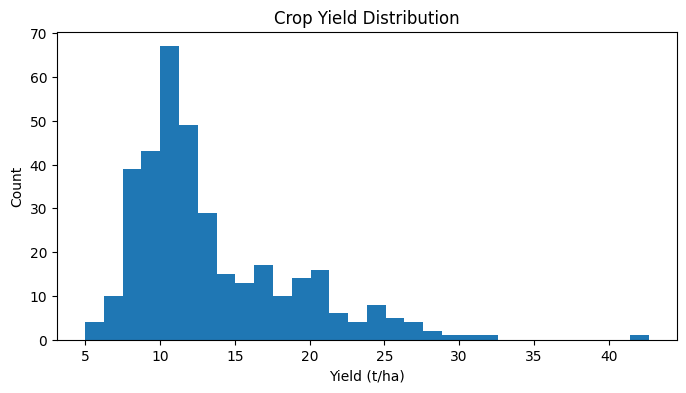

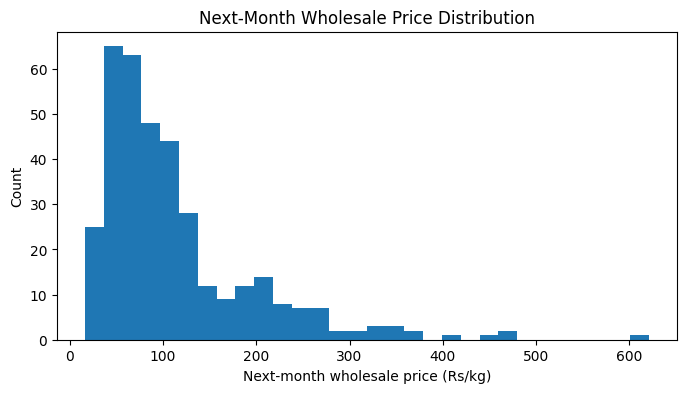

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(
    model_data["Yield_t_ha"].dropna(),
    bins=30
)
plt.xlabel("Yield (t/ha)")
plt.ylabel("Count")
plt.title("Crop Yield Distribution")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(
    model_data[
        "NextMonthWholesalePrice_RsKg"
    ].dropna(),
    bins=30
)
plt.xlabel(
    "Next-month wholesale price (Rs/kg)"
)
plt.ylabel("Count")
plt.title(
    "Next-Month Wholesale Price Distribution"
)
plt.show()

In [10]:
yield_trend = (
    model_data
    .groupby(
        "Year",
        as_index=False
    )["Yield_t_ha"]
    .mean()
)

price_trend = (
    model_data
    .groupby(
        "Year",
        as_index=False
    )[
        "NextMonthWholesalePrice_RsKg"
    ]
    .mean()
)

display(yield_trend.tail())
display(price_trend.tail())

display(
    model_data
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
    .to_frame("missing")
)

print(
    "Duplicate rows:",
    model_data.duplicated().sum()
)

print(
    "Duplicate Crop+Season+Year:",
    model_data
    .duplicated(
        ["Crop", "Season", "Year"]
    )
    .sum()
)

print(
    "Leakage rows:",
    (
        pd.to_datetime(
            model_data["WeatherWindowEnd"]
        )
        >=
        pd.to_datetime(
            model_data["ForecastDate"]
        )
    ).sum()
)

,Year,Yield_t_ha
7,2019,14.367059
8,2020,14.442396
9,2021,13.632279
10,2022,13.357551
11,2023,13.104088


,Year,NextMonthWholesalePrice_RsKg
7,2019,125.362770
8,2020,76.453023
9,2021,107.266176
10,2022,242.668589
11,2023,207.499584


,missing
District,0
Season,0
CropCategory,0
Crop,0
Year,0
Extent,0
Production,0
Yield_t_ha,0
Yield_IQR_Flag,0
AnchorMonth,0


Duplicate rows: 0
Duplicate Crop+Season+Year: 0
Leakage rows: 0


## Required evidence logs

In [11]:
data_dictionary = pd.DataFrame([
    [
        "Crop",
        "Categorical",
        "Vegetable crop name"
    ],
    [
        "Season",
        "Categorical",
        "Maha or Yala"
    ],
    [
        "Year",
        "Integer",
        "Common modelling year, 2012-2023"
    ],
    [
        "Extent",
        "Numeric",
        "Cultivated extent from production data"
    ],
    [
        "Yield_t_ha",
        "Numeric target",
        "Production divided by cultivated extent"
    ],
    [
        "ForecastDate",
        "Date",
        "Yala: 1 April; Maha: 1 September"
    ],
    [
        "Rainfall_3M_mm",
        "Numeric",
        "Rainfall in the three complete months before ForecastDate"
    ],
    [
        "TempMean_3M_C",
        "Numeric",
        "Mean temperature in the three complete months before ForecastDate"
    ],
    [
        "WindSpeed_3M_kmh",
        "Numeric",
        "Mean wind speed in the three complete months before ForecastDate"
    ],
    [
        "SolarRadiation_3M_MJ_m2",
        "Numeric",
        "Mean solar radiation in the three complete months before ForecastDate"
    ],
    [
        "ET0_3M_mm",
        "Numeric",
        "Total ET0 in the three complete months before ForecastDate"
    ],
    [
        "PrevMonthWholesalePrice_RsKg",
        "Numeric feature",
        "Wholesale price from the month before ForecastDate"
    ],
    [
        "NextMonthWholesalePrice_RsKg",
        "Numeric target",
        "Wholesale price for the month after ForecastDate"
    ]
], columns=[
    "Field",
    "Type",
    "Meaning"
])

preprocessing_log = pd.DataFrame([
    [
        "Common time period",
        "Use 2012-2023 for the final modelling table",
        "Both Maha and Yala have complete required data"
    ],
    [
        "Production",
        "Use Member 1 cleaned national vegetable records and calculated yield",
        "Keeps one consistent production source"
    ],
    [
        "Weather",
        "Use only the three full months before each forecast date",
        "Prevents future-weather leakage"
    ],
    [
        "Weather places",
        "Location IDs are checked against locationData.csv before national daily aggregation",
        "Confirms weather locations are valid"
    ],
    [
        "Price",
        "Filter wholesale records and convert weekly prices to monthly crop prices",
        "Matches the business target"
    ],
    [
        "Price feature",
        "Previous-month wholesale price",
        "Available before the target month"
    ],
    [
        "Price target",
        "Next-month wholesale price",
        "Future value to predict"
    ],
    [
        "Missing values",
        "Drop rows missing required model features or targets after alignment",
        "No invented values"
    ],
    [
        "Duplicates",
        "Require unique Crop + Season + Year rows",
        "Avoid duplicated modelling observations"
    ]
], columns=[
    "Step",
    "Decision",
    "Reason"
])

decision_log = pd.DataFrame([
    [
        "ML task",
        "Supervised multi-output regression",
        "Predict yield and next-month wholesale price together"
    ],
    [
        "Yala forecast date",
        "1 April",
        "Uses January-March weather only"
    ],
    [
        "Maha forecast date",
        "1 September",
        "Uses June-August weather only"
    ],
    [
        "Leakage prevention",
        "WeatherWindowEnd must be earlier than ForecastDate",
        "Future weather must never be an input"
    ],
    [
        "Validation strategy",
        "Time-based train/validation/test split",
        "Future years are not mixed into earlier training data"
    ]
], columns=[
    "Decision",
    "Selected_Choice",
    "Reason"
])

eda_log = pd.DataFrame([
    [
        "Final modelling rows",
        len(model_data),
        "Rows remaining after reliable alignment and required-value filtering"
    ],
    [
        "Unique crops",
        model_data["Crop"].nunique(),
        "Crops available for modelling"
    ],
    [
        "Duplicate Crop+Season+Year",
        int(
            model_data
            .duplicated(
                ["Crop", "Season", "Year"]
            )
            .sum()
        ),
        "Must be zero"
    ],
    [
        "Weather leakage rows",
        int(
            (
                pd.to_datetime(
                    model_data["WeatherWindowEnd"]
                )
                >=
                pd.to_datetime(
                    model_data["ForecastDate"]
                )
            ).sum()
        ),
        "Must be zero"
    ],
    [
        "Median yield (t/ha)",
        round(
            float(
                model_data["Yield_t_ha"].median()
            ),
            4
        ),
        "Central yield level"
    ],
    [
        "Median next-month price (Rs/kg)",
        round(
            float(
                model_data[
                    "NextMonthWholesalePrice_RsKg"
                ].median()
            ),
            4
        ),
        "Central target-price level"
    ]
], columns=[
    "Analysis",
    "Observation",
    "Interpretation"
])

data_dictionary.to_csv(
    EVIDENCE_PATH / "Data_Dictionary.csv",
    index=False
)

preprocessing_log.to_csv(
    EVIDENCE_PATH / "Preprocessing_Feature_Log.csv",
    index=False
)

decision_log.to_csv(
    EVIDENCE_PATH / "Decision_Log.csv",
    index=False
)

eda_log.to_csv(
    EVIDENCE_PATH / "EDA_Insight_Log.csv",
    index=False
)

display(data_dictionary)
display(preprocessing_log)
display(decision_log)
display(eda_log)

,Field,Type,Meaning
0,Crop,Categorical,Vegetable crop name
1,Season,Categorical,Maha or Yala
2,Year,Integer,"Common modelling year, 2012-2023"
3,Extent,Numeric,Cultivated extent from production data
4,Yield_t_ha,Numeric target,Production divided by cultivated extent
5,ForecastDate,Date,Yala: 1 April; Maha: 1 September
6,Rainfall_3M_mm,Numeric,Rainfall in the three complete months before F...
7,TempMean_3M_C,Numeric,Mean temperature in the three complete months ...
8,WindSpeed_3M_kmh,Numeric,Mean wind speed in the three complete months b...
9,SolarRadiation_3M_MJ_m2,Numeric,Mean solar radiation in the three complete mon...


,Step,Decision,Reason
0,Common time period,Use 2012-2023 for the final modelling table,Both Maha and Yala have complete required data
1,Production,Use Member 1 cleaned national vegetable record...,Keeps one consistent production source
2,Weather,Use only the three full months before each for...,Prevents future-weather leakage
3,Weather places,Location IDs are checked against locationData....,Confirms weather locations are valid
4,Price,Filter wholesale records and convert weekly pr...,Matches the business target
5,Price feature,Previous-month wholesale price,Available before the target month
6,Price target,Next-month wholesale price,Future value to predict
7,Missing values,Drop rows missing required model features or t...,No invented values
8,Duplicates,Require unique Crop + Season + Year rows,Avoid duplicated modelling observations


,Decision,Selected_Choice,Reason
0,ML task,Supervised multi-output regression,Predict yield and next-month wholesale price t...
1,Yala forecast date,1 April,Uses January-March weather only
2,Maha forecast date,1 September,Uses June-August weather only
3,Leakage prevention,WeatherWindowEnd must be earlier than Forecast...,Future weather must never be an input
4,Validation strategy,Time-based train/validation/test split,Future years are not mixed into earlier traini...


,Analysis,Observation,Interpretation
0,Final modelling rows,359.0000,Rows remaining after reliable alignment and re...
1,Unique crops,18.0000,Crops available for modelling
2,Duplicate Crop+Season+Year,0.0000,Must be zero
3,Weather leakage rows,0.0000,Must be zero
4,Median yield (t/ha),11.7201,Central yield level
5,Median next-month price (Rs/kg),89.0833,Central target-price level


In [12]:
def dataframe_sha256(df):
    csv_bytes = (
        df
        .to_csv(
            index=False,
            date_format="%Y-%m-%d"
        )
        .encode("utf-8")
    )

    return hashlib.sha256(
        csv_bytes
    ).hexdigest()


fingerprints = pd.DataFrame([
    {
        "Dataset": "Production preprocessed",
        "Source": "Preprocessed Datasets/01_production_preprocessed.csv",
        "Loaded_Table_SHA256": dataframe_sha256(prod)
    },
    {
        "Dataset": "Weather preprocessed",
        "Source": "Preprocessed Datasets/02_weather_preprocessed.csv",
        "Loaded_Table_SHA256": dataframe_sha256(weather_3m)
    },
    {
        "Dataset": "Weekly price workbook after header loading",
        "Source": f"Raw Datasets/{PRICE_FILE.name}",
        "Loaded_Table_SHA256": dataframe_sha256(price_raw)
    },
    {
        "Dataset": "Final modelling dataset",
        "Source": "Preprocessed Datasets/03_final_modelling_dataset.csv",
        "Loaded_Table_SHA256": dataframe_sha256(model_data)
    }
])

fingerprints.to_csv(
    EVIDENCE_PATH
    / "dataset_fingerprints.csv",
    index=False
)

display(fingerprints)

,Dataset,Source,Loaded_Table_SHA256
0,Production preprocessed,Preprocessed Datasets/01_production_preprocess...,a94f0781124b1a8f566fa41217e041aad99aa5488c60b8...
1,Weather preprocessed,Preprocessed Datasets/02_weather_preprocessed.csv,2e47c79c5466515426b163c3dadf2a8fa561d3487fde9e...
2,Weekly price workbook after header loading,Raw Datasets/Weekly Average Retail Prices of V...,e1c8b813c57620f541e57c07f26dc8ca4b8ac1e84e2bd6...
3,Final modelling dataset,Preprocessed Datasets/03_final_modelling_datas...,04b41880b9c2483b7c3c6f9b6aa3e2f43621b852a5df31...


In [13]:
final_dataset = (
    PREPROCESSED_PATH
    / "03_final_modelling_dataset.csv"
)

model_data.to_csv(
    final_dataset,
    index=False
)

print("Saved:", price_output)
print("Saved:", final_dataset)
print("Rows:", len(model_data))

print("\nEvidence files:")
for path in sorted(
    EVIDENCE_PATH.glob("*.csv")
):
    print(path.name)

Saved: /content/IT3091---Machine-Learning-Assignment/Preprocessed Datasets/03_price_preprocessed.csv
Saved: /content/IT3091---Machine-Learning-Assignment/Preprocessed Datasets/03_final_modelling_dataset.csv
Rows: 359

Evidence files:
Data_Dictionary.csv
Decision_Log.csv
EDA_Insight_Log.csv
Preprocessing_Feature_Log.csv
dataset_fingerprints.csv


In [ ]:
from getpass import getpass
from google.colab import _message
import subprocess

MEMBER_NAME = "JAYAKODY N.D"
NOTEBOOK_NAME = "03_IT24101090_JAYAKODY_ND_Price_EDA_Preprocessing.ipynb"

FILES_TO_ADD = [
    "Preprocessed Datasets/03_price_preprocessed.csv",
    "Preprocessed Datasets/03_final_modelling_dataset.csv",
    "Evidence Logs/Data_Dictionary.csv",
    "Evidence Logs/Preprocessing_Feature_Log.csv",
    "Evidence Logs/Decision_Log.csv",
    "Evidence Logs/EDA_Insight_Log.csv",
    "Evidence Logs/dataset_fingerprints.csv"
]

current_notebook = _message.blocking_request(
    "get_ipynb",
    request="",
    timeout_sec=10
)

notebook_path = REPO_PATH / NOTEBOOK_NAME

with open(
    notebook_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        current_notebook["ipynb"],
        f,
        ensure_ascii=False,
        indent=1
    )

print("Saved notebook:", notebook_path.name)

github_email = input("GitHub email: ").strip()
github_username = input("GitHub username: ").strip()
github_token = getpass("GitHub Personal Access Token: ")

subprocess.run(
    ["git", "config", "user.name", MEMBER_NAME],
    cwd=REPO_PATH,
    check=True
)

subprocess.run(
    ["git", "config", "user.email", github_email],
    cwd=REPO_PATH,
    check=True
)

for item in [NOTEBOOK_NAME] + FILES_TO_ADD:
    subprocess.run(
        ["git", "add", item],
        cwd=REPO_PATH,
        check=True
    )

status = subprocess.run(
    ["git", "status", "--short"],
    cwd=REPO_PATH,
    text=True,
    capture_output=True,
    check=True
)

print(status.stdout)

if status.stdout.strip():
    subprocess.run(
        [
            "git",
            "commit",
            "-m",
            "Member 3: Update price EDA logs and leakage-safe modelling dataset"
        ],
        cwd=REPO_PATH,
        check=True
    )
else:
    print("Nothing new to commit.")

askpass = Path("/tmp/git_askpass.sh")

askpass.write_text(
    '#!/bin/sh\n'
    'case "$1" in\n'
    '  *Username*) echo "$GITHUB_USERNAME" ;;\n'
    '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
    'esac\n'
)

askpass.chmod(0o700)

env = os.environ.copy()
env["GITHUB_USERNAME"] = github_username
env["GITHUB_TOKEN"] = github_token
env["GIT_ASKPASS"] = str(askpass)

result = subprocess.run(
    ["git", "push", "origin", "main"],
    cwd=REPO_PATH,
    env=env,
    text=True,
    capture_output=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        "Push failed. Check the GitHub username, token and repository permission."
    )

print("Push completed.")